In [4]:
pip install numpy pandas seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [5]:
#Task 2: Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#Task 3: Load and Inspect the Dataset
data = pd.read_csv('data.csv')
print(data.head())
print(data.info())
print(data.describe())

    Age   Salary  Experience Department
0  22.0  25000.0           1         IT
1  25.0  30000.0           2         HR
2   NaN  28000.0           2         IT
3  28.0      NaN           3    Finance
4  35.0  50000.0          10         IT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         8 non-null      float64
 1   Salary      8 non-null      float64
 2   Experience  10 non-null     int64  
 3   Department  10 non-null     object 
dtypes: float64(2), int64(1), object(1)
memory usage: 452.0+ bytes
None
             Age        Salary  Experience
count   8.000000      8.000000   10.000000
mean   31.375000  43375.000000    7.300000
std     7.963084  16843.290313    6.566751
min    22.000000  25000.000000    1.000000
25%    25.750000  29500.000000    2.250000
50%    29.000000  41000.000000    4.000000
75%    36.250000  54000.000000   11.5000

In [7]:
#(a) Detect Missing Values
print(data.isnull().sum())
#(b) Removing Missing Values
data_dropped = data.dropna()


Age           2
Salary        2
Experience    0
Department    0
dtype: int64


In [8]:
#Normalization scales data between 0 and 1.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data[['Age', 'Salary']] = scaler.fit_transform(data[['Age', 'Salary']])


In [9]:
#Standardization transforms data to have mean = 0 and standard deviation = 1.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[['Age', 'Salary']] = scaler.fit_transform(data[['Age', 'Salary']])


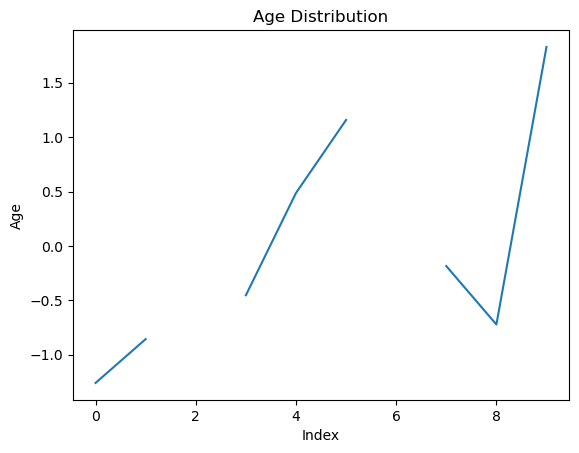

In [10]:
#7.1 Visualization Using Matplotlib
#	Line Plot
plt.plot(data['Age'])
plt.title('Age Distribution')
plt.xlabel('Index')
plt.ylabel('Age')
plt.show()


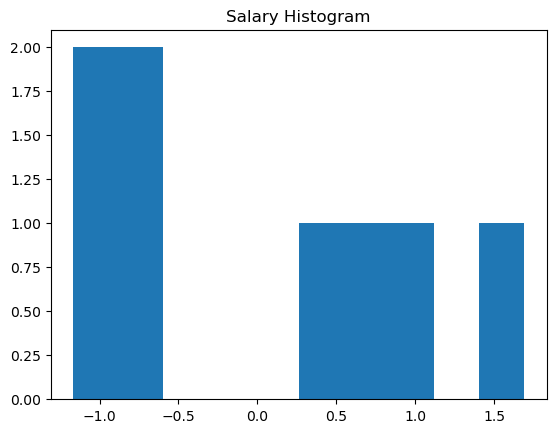

In [11]:
#	Histogram
plt.hist(data['Salary'], bins=10)
plt.title('Salary Histogram')
plt.show()

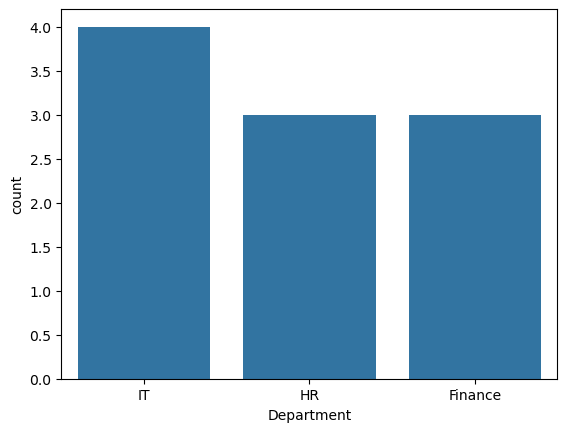

In [12]:
#	Count Plot
sns.countplot(x='Department', data=data)
plt.show()

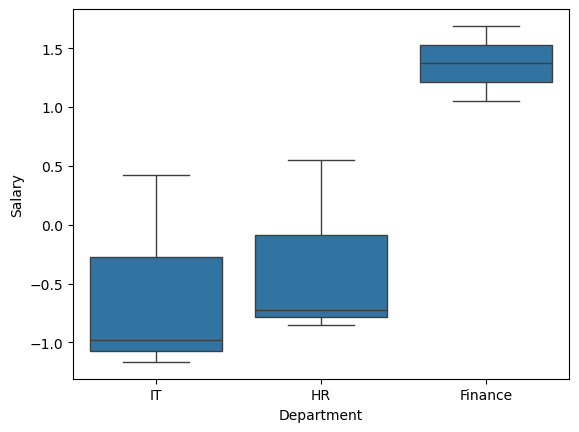

In [13]:
#	Box Plot
sns.boxplot(x='Department', y='Salary', data=data)
plt.show()


In [14]:
#lab 03

In [15]:
#Compute Correlation Matrix
correlation_matrix = data.corr(numeric_only=True)
print(correlation_matrix)

                 Age    Salary  Experience
Age         1.000000  0.999823    0.988664
Salary      0.999823  1.000000    0.996945
Experience  0.988664  0.996945    1.000000


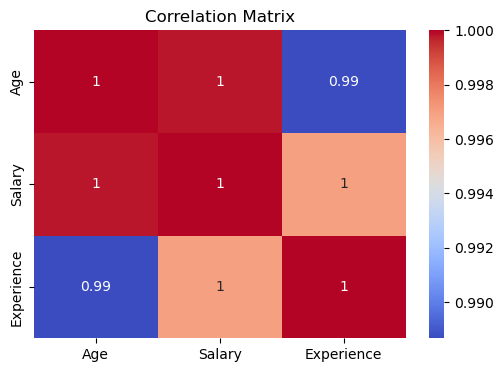

In [16]:
#Visualize Correlation Using Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

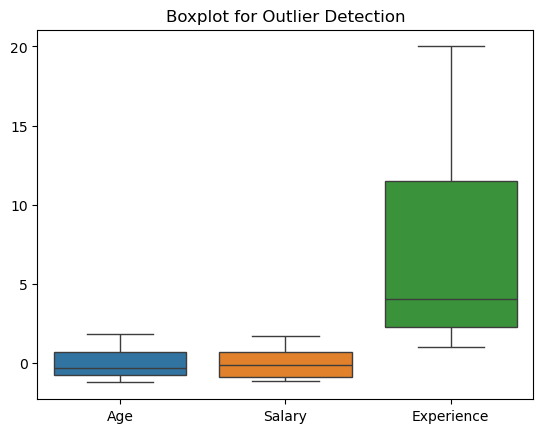

In [17]:
#Detect Outliers Using Boxplot
sns.boxplot(data=data[['Age', 'Salary', 'Experience']])
plt.title('Boxplot for Outlier Detection')
plt.show()

In [31]:
#Detect Outliers Using IQR Method
Q1 = data['Salary'].quantile(0.25)
Q3 = data['Salary'].quantile(0.75)
IQR = Q3 - Q1 
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['Salary'] < lower_bound) | (data['Salary'] > upper_bound)]
print(outliers)

Empty DataFrame
Columns: [Age, Salary, Experience, Salary_per_Experience, Department_HR, Department_IT]
Index: []


In [22]:
#Removing Outliers
data_no_outliers = data[(data['Salary'] >= lower_bound) & (data['Salary'] <=upper_bound)]

In [23]:
# Create new feature safely
data_no_outliers['Salary_per_Experience'] = (data_no_outliers['Salary'] /
data_no_outliers['Experience'])
print(data_no_outliers.head())

        Age    Salary  Experience Department  Salary_per_Experience
0 -1.258595 -1.166263           1         IT              -1.166263
1 -0.855844 -0.848912           2         HR              -0.424456
2       NaN -0.975852           2         IT              -0.487926
4  0.486657  0.420489          10         IT               0.042049
5  1.157907  1.055190          15    Finance               0.070346


C:\Users\PCS\AppData\Local\Temp\ipykernel_30080\3803397796.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_no_outliers['Salary_per_Experience'] = (data_no_outliers['Salary'] /


In [24]:
#One-Hot Encoding
data_encoded = pd.get_dummies(
data_no_outliers,
columns=['Department'],
drop_first=True
)
print(data_encoded.head())

        Age    Salary  Experience  Salary_per_Experience  Department_HR  \
0 -1.258595 -1.166263           1              -1.166263          False   
1 -0.855844 -0.848912           2              -0.424456           True   
2       NaN -0.975852           2              -0.487926          False   
4  0.486657  0.420489          10               0.042049          False   
5  1.157907  1.055190          15               0.070346          False   

   Department_IT  
0           True  
1          False  
2           True  
4           True  
5          False  


In [25]:
X =data_encoded.drop('Salary', axis=1)
y = data_encoded['Salary']

In [29]:
# Train-Test Split
import sklearn as skl
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (6, 5)
Testing set size: (2, 5)


In [30]:
# 1. Handle missing values
data['Age'].fillna(data['Age'].mean(), inplace=True)
data['Salary'].fillna(data['Salary'].median(), inplace=True)
# 2. Feature Engineering
data['Salary_per_Experience'] = data['Salary'] / data['Experience']
# 3. One-Hot Encoding
data = pd.get_dummies(data, columns=['Department'], drop_first=True)
# 4. Define Features & Target
X =data.drop('Salary', axis=1)
y = data['Salary']
# 5. Split Datafrom sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Preprocessing Completed Successfully!")

Preprocessing Completed Successfully!


C:\Users\PCS\AppData\Local\Temp\ipykernel_30080\4270653522.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
C:\Users\PCS\AppData\Local\Temp\ipykernel_30080\4270653522.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa